In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Donchian Channel — Backtest

**Instrument:** SPY, QQQ, IWM (daily bars)
**Signal:** Buy when price breaks above 20-day high. Sell when price breaks below 20-day low.
**Stop loss:** -5%

91 trades, 63.7% WR, 139% return, -12.4% MaxDD from V2 screen.

Uses `shared/` for data, fees, metrics, significance, and results.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees
from _shared.metrics import evaluate_strategy, print_metrics
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [2]:
STRATEGY_NAME = "Donchian Channel"
SAVE_NAME = "donchian_channel"

CHANNEL_PERIOD = 20
STOP_LOSS = -0.05

## 3. Data

In [3]:
SYMBOLS = ["SPY", "QQQ", "IWM"]
START_DATE = "2006-01-01"
END_DATE = "2026-04-01"
STARTING_CAPITAL = 100_000

data_dict = fetch_historical_data(SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

all_data = {}
for sym in SYMBOLS:
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    d = d[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)
    all_data[sym] = d
    print(f"{sym}: {len(d):,} bars, {d['date'].iloc[0].date()} → {d['date'].iloc[-1].date()}")

Fetching SPY...
  2,575 bars
Fetching QQQ...
  2,575 bars
Fetching IWM...
  2,575 bars
SPY: 2,575 bars, 2016-01-04 → 2026-03-31
QQQ: 2,575 bars, 2016-01-04 → 2026-03-31
IWM: 2,575 bars, 2016-01-04 → 2026-03-31


## 4. Backtest Engine

In [4]:
def run_backtest(all_data, signal_fn, alloc_per_sym=0.30, 
                 stop_loss=None, include_fees=True):
    """
    Run backtest across multiple symbols.
    Produces standardized trades DataFrame matching shared.metrics format.
    """
    all_trades = []
    
    for sym, df in all_data.items():
        df = df.copy()
        df = signal_fn(df)
        df = df.dropna(subset=["signal"]).reset_index(drop=True)
        
        equity = STARTING_CAPITAL * alloc_per_sym
        in_position = False
        entry_price = entry_date = None
        shares = 0
        
        for i in range(len(df)):
            row = df.iloc[i]
            
            if in_position:
                # Stop loss check
                if stop_loss and (row["close"] - entry_price) / entry_price <= stop_loss:
                    exit_price = entry_price * (1 + stop_loss)
                    gross = shares * (exit_price - entry_price)
                    fees = calculate_fees(shares, entry_price, exit_price, "long") if include_fees else 0.0
                    net = gross - fees
                    eq_before = equity
                    equity += net
                    all_trades.append({
                        "entry_time": entry_date, "exit_time": row["date"],
                        "position": "long",
                        "entry_price": round(entry_price, 4),
                        "exit_price": round(exit_price, 4),
                        "exit_reason": "stop_loss",
                        "risk": round(abs(stop_loss) * entry_price, 4),
                        "shares": shares,
                        "gross_pnl": round(gross, 2),
                        "fees": round(fees, 2),
                        "net_pnl": round(net, 2),
                        "equity_before": round(eq_before, 2),
                        "equity": round(equity, 2),
                    })
                    in_position = False
                    continue
                
                # Normal exit
                if row["signal"] == 0:
                    exit_price = row["close"]
                    gross = shares * (exit_price - entry_price)
                    fees = calculate_fees(shares, entry_price, exit_price, "long") if include_fees else 0.0
                    net = gross - fees
                    eq_before = equity
                    equity += net
                    all_trades.append({
                        "entry_time": entry_date, "exit_time": row["date"],
                        "position": "long",
                        "entry_price": round(entry_price, 4),
                        "exit_price": round(exit_price, 4),
                        "exit_reason": "signal_off",
                        "risk": round(entry_price * 0.05, 4),
                        "shares": shares,
                        "gross_pnl": round(gross, 2),
                        "fees": round(fees, 2),
                        "net_pnl": round(net, 2),
                        "equity_before": round(eq_before, 2),
                        "equity": round(equity, 2),
                    })
                    in_position = False
            
            else:
                if row["signal"] == 1 and equity > 0:
                    entry_price = row["close"]
                    entry_date = row["date"]
                    shares = int((equity * 0.95) / entry_price)
                    if shares > 0:
                        in_position = True
        
        # Close open position
        if in_position:
            row = df.iloc[-1]
            exit_price = row["close"]
            gross = shares * (exit_price - entry_price)
            fees = calculate_fees(shares, entry_price, exit_price, "long") if include_fees else 0.0
            net = gross - fees
            eq_before = equity
            equity += net
            all_trades.append({
                "entry_time": entry_date, "exit_time": row["date"],
                "position": "long",
                "entry_price": round(entry_price, 4),
                "exit_price": round(exit_price, 4),
                "exit_reason": "end_of_data",
                "risk": round(entry_price * 0.05, 4),
                "shares": shares,
                "gross_pnl": round(gross, 2),
                "fees": round(fees, 2),
                "net_pnl": round(net, 2),
                "equity_before": round(eq_before, 2),
                "equity": round(equity, 2),
            })
    
    if not all_trades:
        print("No trades generated!")
        return pd.DataFrame()
    
    out = pd.DataFrame(all_trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"] = pd.to_datetime(out["exit_time"])
    # Rebuild equity sequentially (across all symbols combined)
    out = out.sort_values("exit_time").reset_index(drop=True)
    eq = STARTING_CAPITAL
    for i in range(len(out)):
        out.loc[i, "equity_before"] = round(eq, 2)
        eq += out.loc[i, "net_pnl"]
        out.loc[i, "equity"] = round(eq, 2)
    return out

## 5. Signal & Run

In [5]:
def donchian_signal(df):
    df = df.copy()
    df["upper"] = df["high"].rolling(window=CHANNEL_PERIOD).max().shift(1)
    df["lower"] = df["low"].rolling(window=CHANNEL_PERIOD).min().shift(1)
    signal = []
    in_pos = False
    for i in range(len(df)):
        row = df.iloc[i]
        if pd.isna(row.get("upper", np.nan)):
            signal.append(0)
            continue
        if not in_pos and row["close"] >= row["upper"]:
            in_pos = True
        elif in_pos and row["close"] <= row["lower"]:
            in_pos = False
        signal.append(1 if in_pos else 0)
    df["signal"] = signal
    return df

results = run_backtest(all_data, donchian_signal, stop_loss=STOP_LOSS)
print(f"Total trades: {len(results)}")

Total trades: 91


## 6. Analysis

  Strategy             Donchian Channel
  Total Return             139.33%
  Annualized                 6.17
  Max Drawdown             -12.42%
  Sharpe                     6.72
  Sortino                   36.53
  Profit Factor              3.64
  Trades               91
  Win Rate                  63.74%
  Avg Win              $    3,338.33
  Avg Loss             $   -1,610.15
  Long Trades          91
  Long PnL             $  140,487.94
  Long WR                   63.74%
  Short Trades         0
  Short PnL            0
  Short WR             0
  Total Fees           $      480.88
  Final Equity         $  240,487.94

Yearly Returns:
  2016: 1.87%
  2017: 10.15%
  2018: 5.92%
  2019: 3.12%
  2020: 24.95%
  2021: 12.71%
  2022: -5.92%
  2023: 10.3%
  2024: 12.82%
  2025: 3.73%
  2026: -0.73%


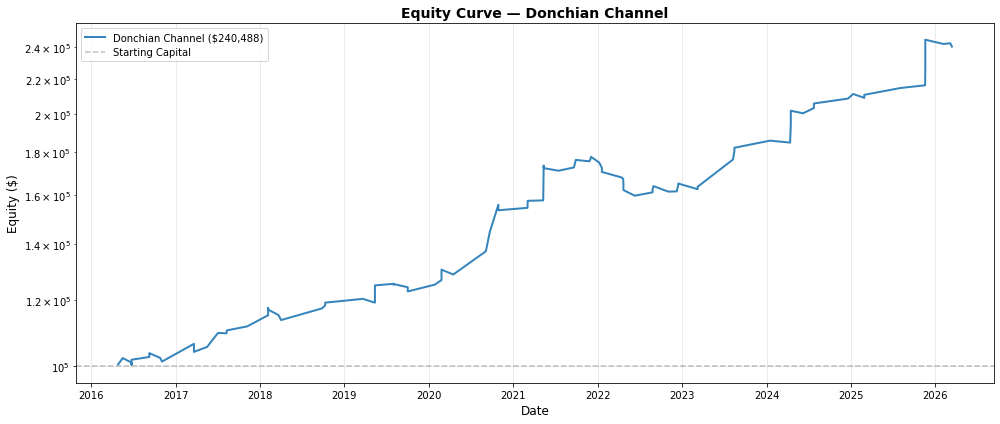

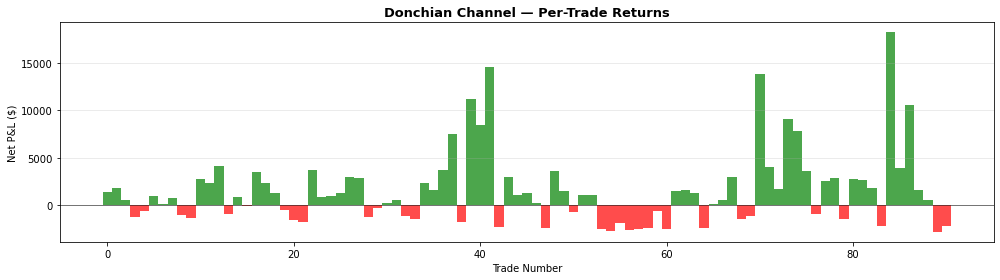

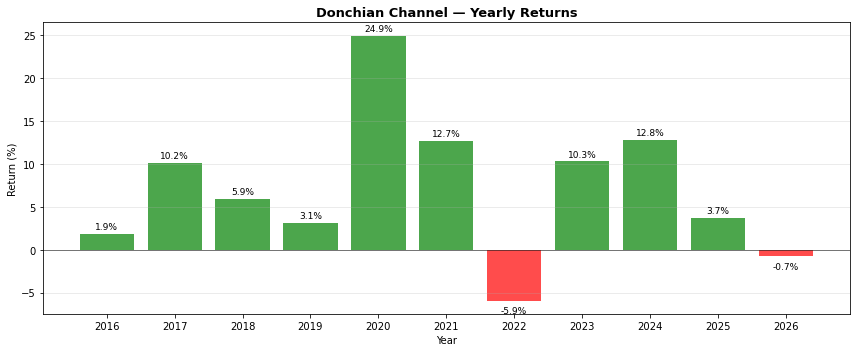


STATISTICAL SIGNIFICANCE — Donchian Channel

1. t-test (returns > 0)
   Mean return:  0.9954% per trade
   t-statistic:  4.0372
   p-value:      5.7e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   6.7555
   95% CI:            [4.3063, 9.1936]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   6.7555
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


In [6]:
if not results.empty:
    metrics = evaluate_strategy(results, STRATEGY_NAME)
    print_metrics(metrics)
    
    plot_equity_curve(results, label=STRATEGY_NAME, starting_capital=STARTING_CAPITAL)
    plot_trade_returns(results, title=f"{STRATEGY_NAME} — Per-Trade Returns")
    plot_yearly_returns(metrics, title=f"{STRATEGY_NAME} — Yearly Returns")
    
    if len(results) >= 5:
        report = full_significance_report(results, strategy_name=STRATEGY_NAME)
        print_significance_report(report)

## 7. Save

In [7]:
if not results.empty:
    save_trades(results, SAVE_NAME)

Saved 91 trades → results\donchian_channel_trades.csv
